In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy as sp
import os

In [2]:
from utils.distribution import Distribution

distribution_root = "../distributions/ellipse"
distribution_name = "U.dat"

dtb = Distribution.load_from_file(os.path.join(distribution_root, distribution_name))

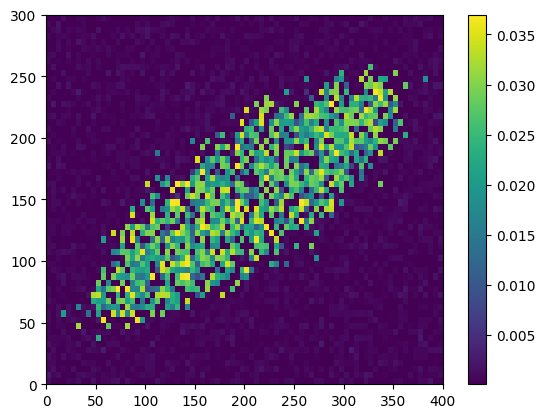

In [3]:
U = dtb.get_col("Uraninite")
dtb.plot("Uraninite")

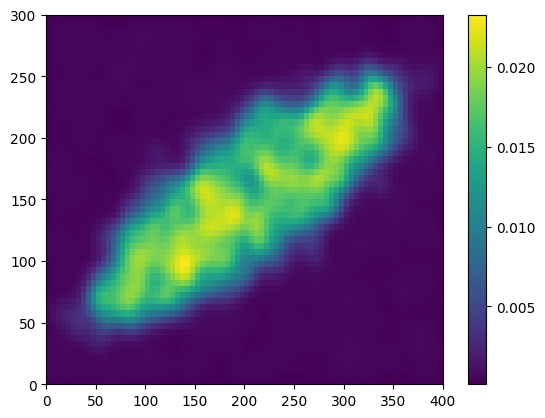

In [4]:
U_smoothed = dtb.smoothen("Uraninite", "U_smoothed", 8)
dtb.plot("U_smoothed")

In [ ]:
gx, gy = np.meshgrid(dtb.x, dtb.y)
grad_U = np.gradient(U_smoothed)
def evaluate_gradient(x, y):
    i = int(np.floor(dtb.NX * (x - dtb.x.min()) / (dtb.x.max() - dtb.x.min())))
    j = int(np.floor(dtb.NY * (y - dtb.y.min()) / (dtb.y.max() - dtb.y.min())))
    return grad_U[1][j,i], grad_U[0][j,i]

def function_sum(wells, f):
    filter = np.zeros(U.shape)
    for [x, y] in wells:
        filter += f((x - gx) ** 2 + (y - gy) ** 2)
    return filter

def estimated_production_filter(injectors, producers, R):
    filter_injectors = function_sum(injectors, lambda d: np.exp(-d/(2*R**2)))
    filter_producers = function_sum(producers, lambda d: np.exp(-d/(2*R**2)))
    filter_injectors = np.minimum(filter_injectors, 1)
    filter_producers = np.minimum(filter_producers, 1)

    return filter_injectors * filter_producers

    closeness_injectors = function_sum(injectors, lambda d: 1/np.pow(d, 1))
    closeness_producers = function_sum(producers, lambda d: 1/np.pow(d, 1))
    closeness = closeness_injectors * closeness_producers

    return np.maximum(0, filter_injectors * filter_producers - closeness * 30)

def estimated_U_production(injectors, producers, R):
    filter = estimated_production_filter(injectors, producers, R)
    porosity = 0.23
    Vcell = (400/80) * (300/60) * 12            # m3
    Vwater = filter * Vcell * porosity * 1000   # L
    return np.sum(Vwater * U) * 270 / 1e6       # T

def filter_wells(wells, R):
    estimated_wells_individual_production = np.array(list(map(lambda pos: (function_sum([pos], lambda d: np.exp(-d/(2*R**2))) * U).sum(), wells)))
    valid_indices = list(filter(lambda i: estimated_wells_individual_production[i] > estimated_wells_individual_production.max() / 4, range(len(wells))))
    return [ wells[i] for i in valid_indices ]

def save_geometry(geometry_name, injectors, producers):
    flow_injectors = len(injectors) / len(producers)
    DX, DY, DZ = 5, 5, 12

    path = os.path.join(distribution_root, geometry_name + ".geo")
    file = open(path, "w")

    for i, [ x, y ] in enumerate(producers):
        file.write(f"zone producteur_{i+1} {{\n")
        file.write(f"  geometry = rectangle {x:.2f}, {y:.2f}, 6 {DX}, {DY}, {DZ} m\n")
        file.write(f"  global-flux producteur_{i+1} \n")
        file.write(f"  geochem = aquifer\n")
        file.write(f"  source = -1 m3/h\n}}\n\n")

    for i, [ x, y ] in enumerate(injectors):
        file.write(f"zone injecteur_{i+1} {{\n")
        file.write(f"  geometry = rectangle {x:.2f}, {y:.2f}, 6 {DX}, {DY}, {DZ} m\n")
        file.write(f"  global-flux injecteur_{i+1} \n")
        file.write(f"  geochem = aquifer\n")
        file.write(f"  source = {flow_injectors} m3/h using leaching_solution_20\n")
        file.write(f"  modify at 30 days, source = {flow_injectors} m3/h using leaching_solution\n}}\n\n")

    file.close()

def plot_estimated_production(injectors, producers, R):
    estimated_production = estimated_production_filter(injectors, producers, R)
    plt.pcolormesh(dtb.x, dtb.y, estimated_production * U_smoothed)
    for [x, y] in injectors:
        plt.scatter(x, y, marker='x', color='red')
    for [x, y] in producers:
        plt.scatter(x, y, marker='x', color='white')
    print(f"Estimated production: {estimated_U_production(injectors, producers, R)} T")
    print(f"{len(injectors)} injectors, {len(producers)} producers")

optimal delta: [19.99679847 -8.4896966 ]
Estimated production: 318.02013413228957
9 injectors, 5 producers


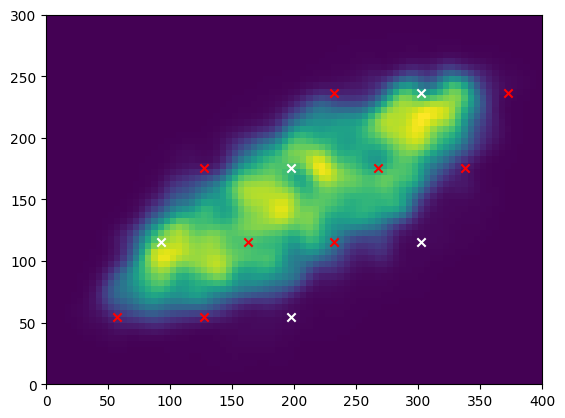

In [69]:
# HEXAGONS

R = 70      # m
injectors = []
producers = []

x, y = dtb.x_min, dtb.y_min
i, j = 0, 0
while x < dtb.x_max and y < dtb.y_max:
    if i % 3 == 1:
        producers.append([ x, y ])
    else:
        injectors.append([ x, y ])
    x += R
    i += 1
    if x > dtb.x_max:
        j += 1
        i = (j % 2) * 2
        y += R * np.cos(np.pi / 6)
        x = dtb.x_min + (j % 2) * R / 2

# injectors = filter_wells(np.array(injectors), R*0.6)
# producers = filter_wells(np.array(producers), R*0.6)

def hex_opt_error(opt_X):
    return - estimated_U_production(injectors + opt_X, producers + opt_X, R/2)

res = sp.optimize.minimize(
    hex_opt_error,
    np.array([ 0, 0 ]),
    bounds = [ (-R, R), (-R, R) ],
    # method = "Nelder-Mead"
)

print(f"optimal delta: {res.x}")
injectors = filter_wells(injectors + res.x, R*0.6)
producers = filter_wells(producers + res.x, R*0.6)

plot_estimated_production(injectors, producers, R*0.6)

Estimated production: 15.839592514435333
19 injectors, 10 producers


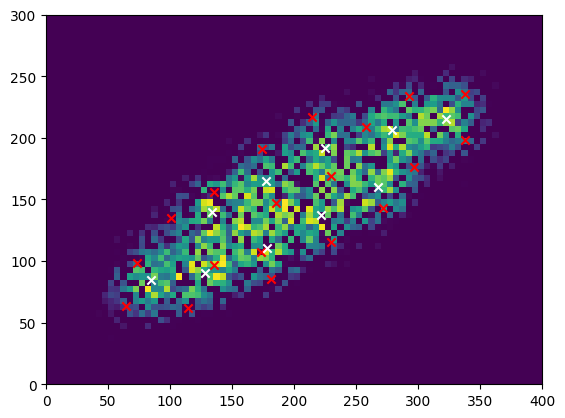

In [7]:
# DYNAMIC PLACEMENT

N_injectors = 20
N_producers = 10

injectors = np.array([ dtb.generate("U_smoothed") for _ in range(N_injectors) ])
producers = np.array([ dtb.generate("U_smoothed") for _ in range(N_producers) ])
R = 20

def decompose_opt_X(opt_X):
    injectors = opt_X[0:N_injectors*2].reshape((N_injectors, 2))
    producers = opt_X[N_injectors*2: ].reshape((N_producers, 2))
    return injectors, producers

def opt_error(opt_X):
    injectors, producers = decompose_opt_X(opt_X)
    return - estimated_U_production(injectors, producers, R)

res = sp.optimize.minimize(
    opt_error,
    np.concatenate((injectors.reshape(N_injectors*2), producers.reshape(N_producers*2))),
    bounds = [ (dtb.x.min(), dtb.x.max()) if i % 2 == 0 else (dtb.y.min(), dtb.y.max()) for i in range(N_injectors * 2 + N_producers * 2) ],
    # method = "Nelder-Mead"
)

injectors, producers = list(map(lambda wells: filter_wells(wells, R), decompose_opt_X(res.x)))

plot_estimated_production(injectors, producers, R)

In [9]:
save_geometry("optimized_1", injectors, producers)

2
4
6
5
3
6
4
3
2


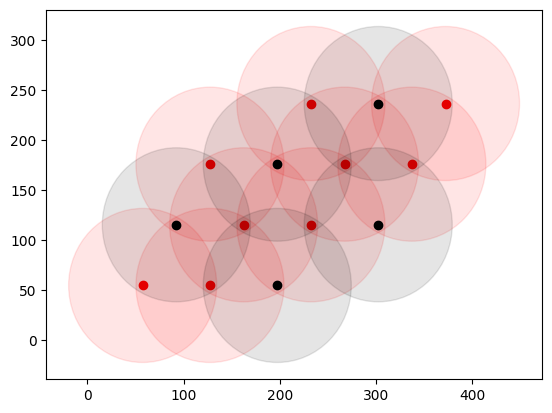

In [90]:
fig, ax = plt.subplots()

all_wells = injectors + producers
for i, [ x, y ] in enumerate(injectors):
    plt.scatter(x, y, color="red")
    c = plt.Circle((x, y), R*1.1, color="red", alpha=0.1)
    ax.add_patch(c)
    in_circle = len(list(filter(lambda w: (w[0]-x)**2 + (w[1]-y)**2 <= R**2*1.1, all_wells))) - 1
    print(in_circle)
for i, [ x, y ] in enumerate(producers):
    plt.scatter(x, y, color="black")
    c = plt.Circle((x, y), R*1.1, color="black", alpha=0.1)
    ax.add_patch(c)